# ***Lab 05. Image filters***

1. Dùng máy ảnh quay một vật thể chuyển động, độ dài tầm 5-10 giây.

2. Lấy trung bình 15 frames đầu tiên -> ảnh J2. Lưu ý, điều chỉnh thế nào để ảnh J2 nhòa.

3. Khử nhòa ảnh bằng: lowpass filter, box filter, gauss filter.

4. Khử nhòa ảnh bằng IFT (Không cần cài đặt lại)

5. Tính đạo hàm theo phương x và phương y, cũng như gradient magnitude của ảnh J2

6. Tách biên bằng dialation của J2 (sử dụng kết hợp binarize, dialation, substraction).

7. So sánh kết quả câu 5-6.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_images(panels, figsize=None):
    if figsize is None:
        figsize = (5 * len(panels), 5)

    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    if len(panels) == 1:
        axes = [axes]

    for ax, (subtitle, image) in zip(axes, panels):
        ax.set_title(subtitle)
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 1. Dùng máy ảnh quay một vật thể chuyển động, độ dài tầm 5-10 giây. 

In [2]:
video_path = 'video.mp4'

## 2. Lấy trung bình 15 frames đầu tiên -> ảnh J2. Lưu ý, điều chỉnh thế nào để ảnh J2 nhòa.

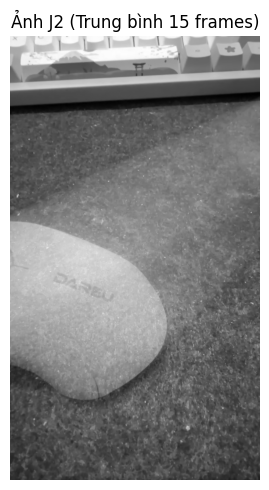

In [11]:
def get_average_frames(video_path, start_frame=0, num_frames=15):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Không thể mở video tại: {video_path}")
        return None
    
    # Đặt vị trí frame bắt đầu
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
    frames = []
    for i in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            print(f"Đã hết video ở frame thứ {start_frame + i}. Chỉ lấy được {i} frames.")
            break
        # Chuyển frame sang ảnh xám để dễ xử lý cho các câu sau
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame)
        
    cap.release()
    
    if not frames:
        return None
        
    # Tính trung bình các frames
    # Sử dụng kiểu float32 để tránh tràn số khi cộng
    avg_frame = np.mean(frames, axis=0).astype(np.uint8)
    return avg_frame

# Thực thi
J2 = get_average_frames(video_path, start_frame=20, num_frames=15)

show_images([("Ảnh J2 (Trung bình 15 frames)", J2)])

## 3. Khử nhòa ảnh bằng: lowpass filter, box filter, gauss filter.

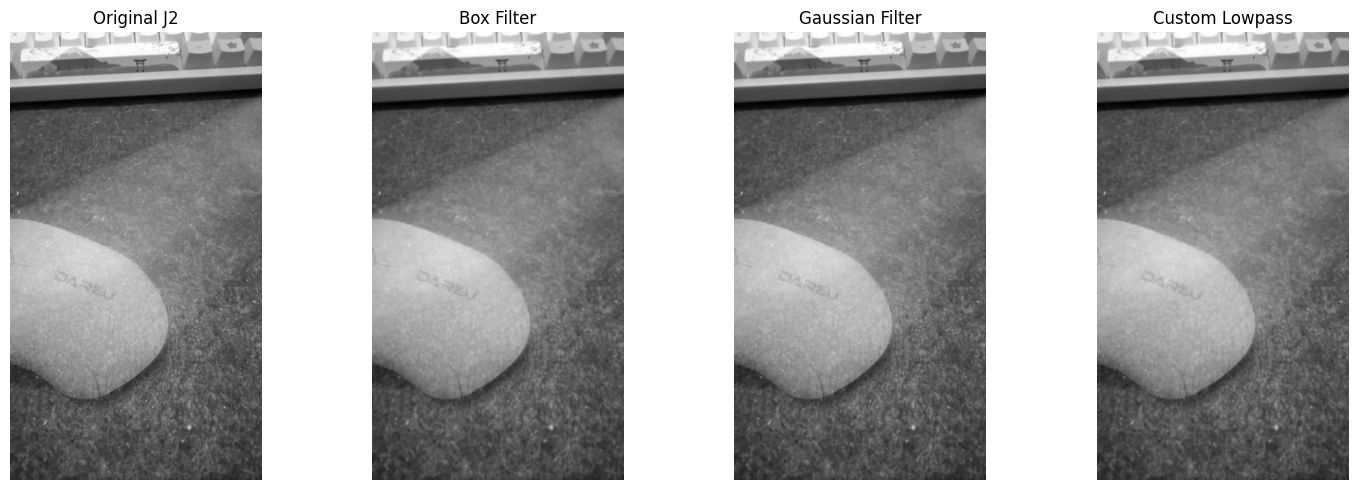

In [12]:
# 1. Box Filter (sử dụng hàm blur)
box_filtered = cv2.blur(J2, (5, 5))

# 2. Gaussian Filter
gauss_filtered = cv2.GaussianBlur(J2, (5, 5), 0)

# 3. Custom Lowpass Filter (Sử dụng kernel 2D tùy chỉnh)
# Ví dụ tạo một kernel lowpass hình tròn đơn giản (disk filter)
kernel_size = 5
kernel_lowpass = np.ones((kernel_size, kernel_size), np.float32)
kernel_lowpass[0, 0] = kernel_lowpass[0, 4] = kernel_lowpass[4, 0] = kernel_lowpass[4, 4] = 0
kernel_lowpass = kernel_lowpass / np.sum(kernel_lowpass)
lowpass_filtered = cv2.filter2D(J2, -1, kernel_lowpass)

# Hiển thị kết quả
panels = [
    ("Original J2", J2),
    ("Box Filter", box_filtered),
    ("Gaussian Filter", gauss_filtered),
    ("Custom Lowpass", lowpass_filtered)
]
show_images(panels, figsize=(15, 5))

## 4. Khử nhòa ảnh bằng IFT (Không cần cài đặt lại)

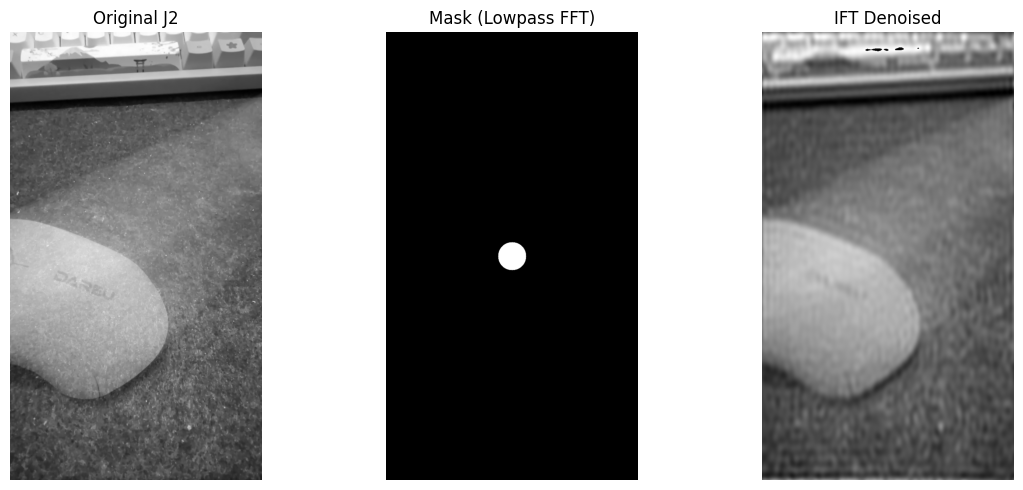

In [13]:
# Biến đổi Fourier
f = np.fft.fft2(J2)
fshift = np.fft.fftshift(f)

# Lấy kích thước ảnh và tâm
rows, cols = J2.shape
crow, ccol = rows // 2, cols // 2

# Tạo mặt nạ mask (Lowpass Filter), hình tròn với bán kính R
r = 40
mask = np.zeros((rows, cols), np.uint8)
cv2.circle(mask, (ccol, crow), r, 1, thickness=-1)

# Áp dụng mask vào phổ tần số
fshift_filtered = fshift * mask

# Biến đổi Fourier ngược (IFT)
f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_ishift)
img_ift = np.abs(img_back).astype(np.uint8)

panels = [
    ("Original J2", J2),
    ("Mask (Lowpass FFT)", mask * 255),
    ("IFT Denoised", img_ift)
]
show_images(panels, figsize=(12, 5))

## 5. Tính đạo hàm theo phương x và phương y, cũng như gradient magnitude của ảnh J2

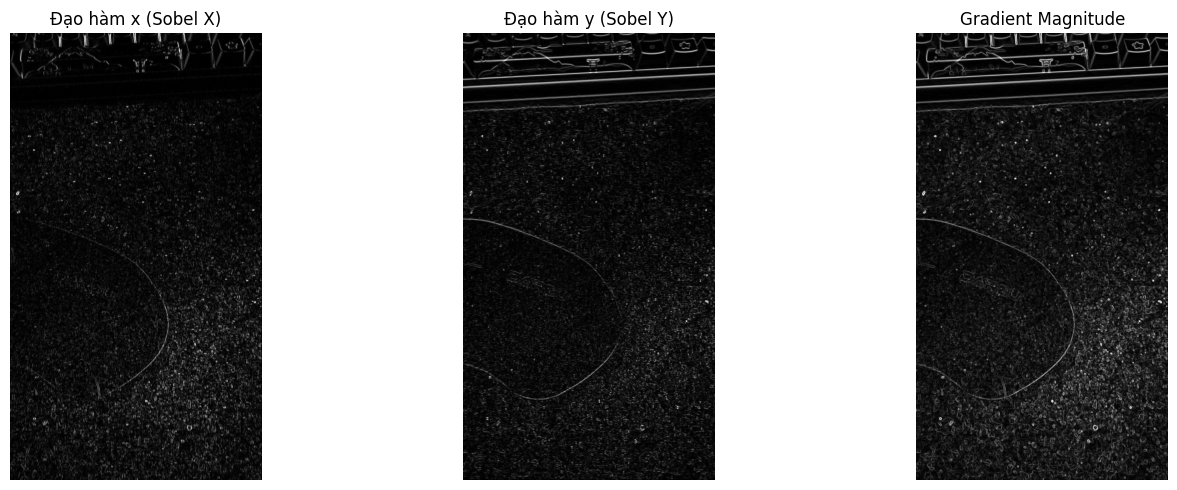

In [14]:
# Dùng bộ lọc Sobel với kiểu dữ liệu CV_64F để giữ lại các giá trị âm
sobel_x = cv2.Sobel(J2, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(J2, cv2.CV_64F, 0, 1, ksize=3)

# Tính Gradient Magnitude
grad_magnitude = cv2.magnitude(sobel_x, sobel_y)

# Chuẩn hóa về [0, 255] để hiển thị
sobel_x_show = cv2.convertScaleAbs(sobel_x)
sobel_y_show = cv2.convertScaleAbs(sobel_y)
grad_mag_show = cv2.convertScaleAbs(grad_magnitude)

panels_grad = [
    ("Đạo hàm x (Sobel X)", sobel_x_show),
    ("Đạo hàm y (Sobel Y)", sobel_y_show),
    ("Gradient Magnitude", grad_mag_show)
]
show_images(panels_grad, figsize=(15, 5))

## 6. Tách biên bằng dialation của J2 (sử dụng kết hợp binarize, dialation, substraction).

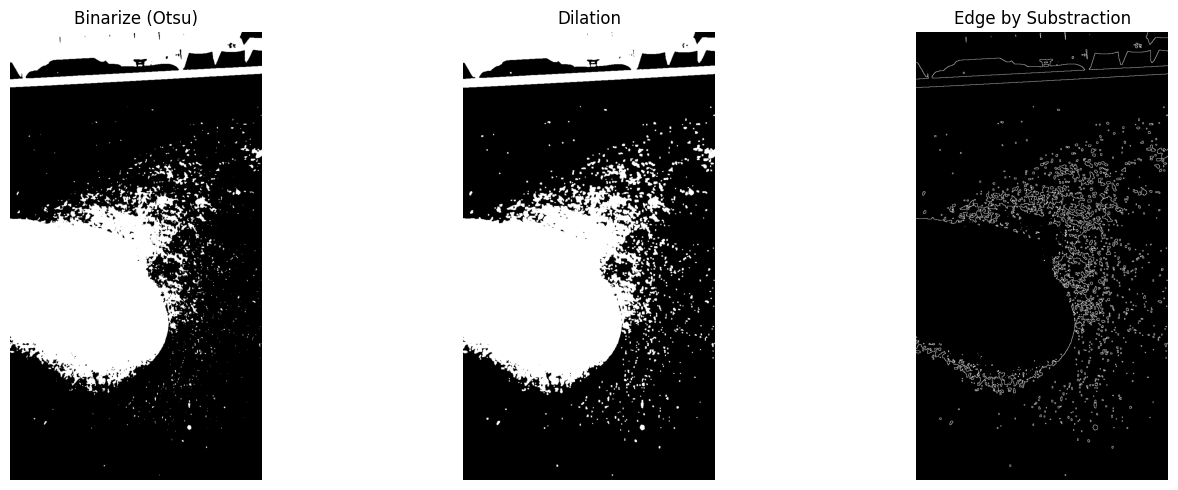

In [15]:
# 1. Binarize (Nhị phân hóa) - Dùng Otsu Thresholding để tự động tìm ngưỡng
_, binary_J2 = cv2.threshold(J2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Dilation (Phình to các vùng trắng)
kernel_morph = np.ones((3, 3), np.uint8)
dilated_J2 = cv2.dilate(binary_J2, kernel_morph, iterations=1)

# 3. Substraction (Trừ ảnh binarize gốc khỏi ảnh đã dilation)
# Phép toán này tương đương với Morphological Boundary Extraction
boundary_dilation = cv2.subtract(dilated_J2, binary_J2)

panels_morph = [
    ("Binarize (Otsu)", binary_J2),
    ("Dilation", dilated_J2),
    ("Edge by Substraction", boundary_dilation)
]
show_images(panels_morph, figsize=(15, 5))

## 7. So sánh kết quả câu 5-6.

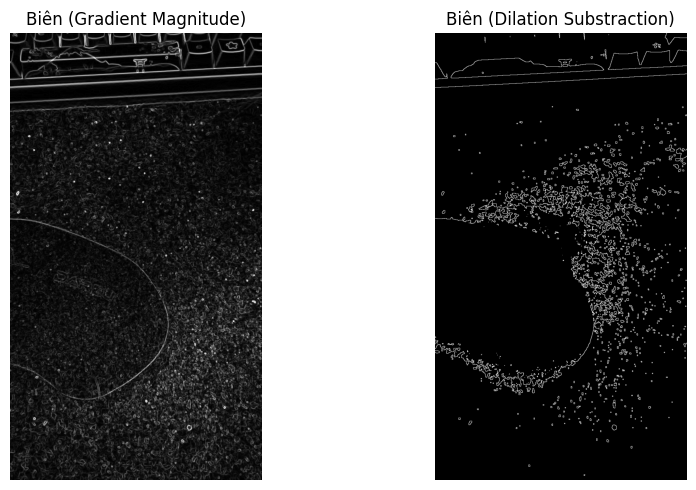

In [16]:
# Hiển thị cạnh nhau để so sánh
panels_compare = [
    ("Biên (Gradient Magnitude)", grad_mag_show),
    ("Biên (Dilation Substraction)", boundary_dilation)
]
show_images(panels_compare, figsize=(10, 5))